In [1]:
import sys
import os
from pathlib import Path

# Robustly find the project root
current_dir = Path(os.getcwd()).resolve()
project_root = None

# Walk up until we find 'model' and 'networks' (current directory structure)
d = current_dir
for _ in range(5):
    if (d / "model").exists() and (d / "networks").exists():
        project_root = d
        break
    if d.parent == d:
        break
    d = d.parent

if project_root:
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    print(f"Project root found at: {project_root}")
else:
    print("Warning: Project root not found automatically. Using absolute fallback.")
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '')))


Project root found at: /Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality


# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [2]:
from utils.imports import *
from model.vectorized_model import VectorizedModel
import matplotlib.pyplot as plt


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../../networks/citation_data/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    # Fix for networkx expecting 'edges' instead of 'links' or vice-versa
    if "links" in data and "edges" not in data:
        data["edges"] = data["links"]
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../../networks/citation_data/pud_final.json


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality/.venv/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


In [4]:
# n_agents = 1000
# my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

## Try with Bayes Agent (Vectorized)

In [5]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=50000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 50000/50000 [00:27<00:00, 1814.61it/s]


steps:  50000
conclusion:  0.632183908045977
conclusion core 0.8461538461538461


,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,0.908036,0.624750,0.062695,0.269318,0.040233,0.537050,0.541784,0.363878,0.551616,0.909416,...,0.838596,0.730301,0.034567,0.143806,0.480797,0.331409,0.975667,0.842337,0.489052,0.620880
1,0.908702,0.626624,0.062695,0.267746,0.040233,0.529086,0.537809,0.362029,0.551616,0.908755,...,0.840750,0.728723,0.034835,0.142824,0.480797,0.331409,0.975476,0.843397,0.487054,0.617107
2,0.910021,0.628494,0.062695,0.269318,0.040543,0.529086,0.535820,0.360183,0.549636,0.908089,...,0.838596,0.733441,0.034301,0.142824,0.480797,0.334964,0.975856,0.841272,0.485055,0.611420


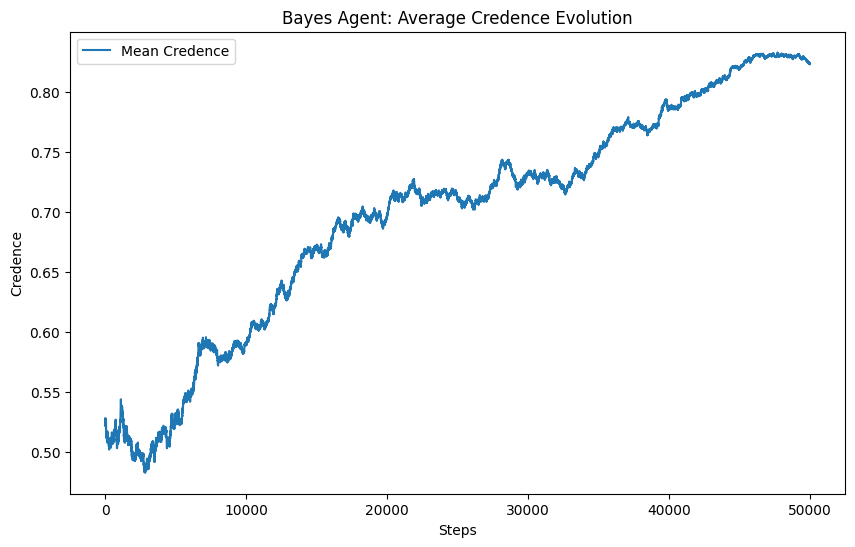

In [6]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [7]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

 95%|█████████▍| 9495/10000 [00:10<00:00, 943.96it/s] 


steps:  9496
conclusion:  0.6091954022988506


,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,"[0.13763715628961526, 0.978328820038602]","[0.6170663273588712, 0.10674908104110833]","[0.7307582309011685, 0.3768101878970513]","[0.054426726174577125, 0.42269227895253336]","[0.07661458248068997, 0.7597639363033196]","[0.24170515568398301, 0.8143044696336164]","[0.7284453796654404, 0.5482887096816578]","[0.14395862061325573, 0.18620066037396385]","[0.9981693441313655, 0.20044351425452006]","[0.9042101828458878, 0.5009558406336108]",...,"[0.9999999995399326, 0.1536309276782059]","[0.5912415460499414, 0.8710332187769948]","[0.9898213385171767, 0.0060811057642242775]","[0.9944302159021466, 0.660060921945253]","[0.9769736592667566, 0.3753292867262347]","[0.8242576291108087, 9.541144104192939e-07]","[0.9759884594530257, 0.1498167066398459]","[0.3350075896070214, 0.36685031635980603]","[0.09413115743292905, 0.5376843926084505]","[0.5392979499172791, 0.17486319603131756]"
1,"[0.4664964049856734, 0.5615224410466997]","[0.4716840368928321, 0.6796506456853437]","[0.6255450212320273, 0.4708676497912224]","[0.1644840498456472, 0.4474150530228025]","[0.3060025136706368, 0.5267339052156088]","[0.2441477240962016, 0.37463366328615055]","[0.34187587252168333, 0.5252551687831424]","[0.5143187295777852, 0.3432572941579584]","[0.5445682202783015, 0.21417500950552532]","[0.6410519679311865, 0.5313834444481436]",...,"[0.39705227951877714, 0.5725004538914328]","[0.341993541965076, 0.46060258200304854]","[0.6118793342110955, 0.6059925854073187]","[0.39440653097120487, 0.46468580895991024]","[0.4531429120141329, 0.7590774264135297]","[0.4134171421665113, 9.114267687621377e-09]","[0.49988656864372893, 0.1254218314857739]","[0.5639104842690952, 0.4310611430457238]","[0.7927140390756042, 0.30081634432937565]","[0.5028555126294043, 0.7293350621821081]"
2,"[0.583826227606914, 0.42255375959584424]","[0.25569893001345706, 0.694881002691137]","[0.6056942825470559, 0.3467463989923508]","[0.37256560489707125, 0.3752805291139493]","[0.5408881992513445, 0.5528387641454848]","[0.2832141961056487, 0.43253450781023756]","[0.4535525022891656, 0.5610160000166975]","[0.6076954176730044, 0.3398274287545986]","[0.5399415782721791, 0.6168031293929261]","[0.314788350543361, 0.8006837101940748]",...,"[0.6251926236604, 0.490508799613058]","[0.4931974813458186, 0.3935033000761353]","[0.48784309642531076, 0.5644659422556139]","[0.5348263610104279, 0.4014658627902373]","[0.5401323930413033, 0.3275764312527908]","[0.5585238419952965, 8.798176735377419e-06]","[0.5509954791069962, 0.29885368613006996]","[0.5238603330033715, 0.3042782906827073]","[0.45783344950823257, 0.6079023496238875]","[0.43671028651219324, 0.3775381852769272]"


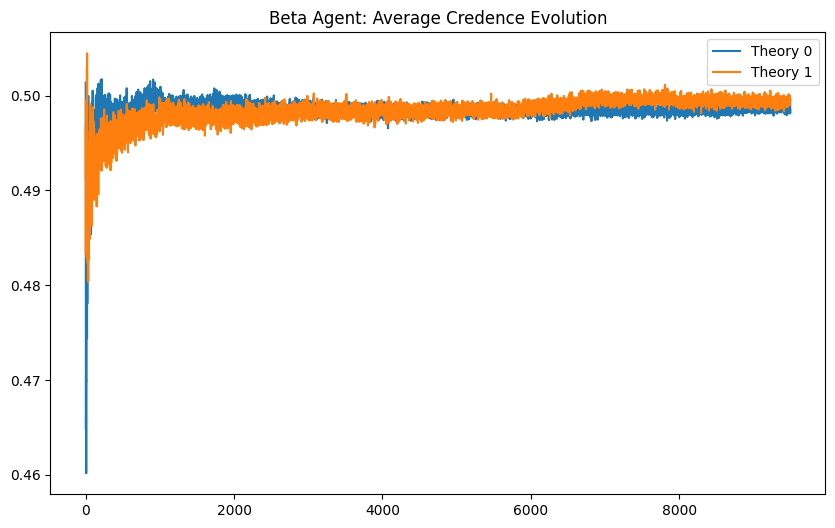

In [8]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

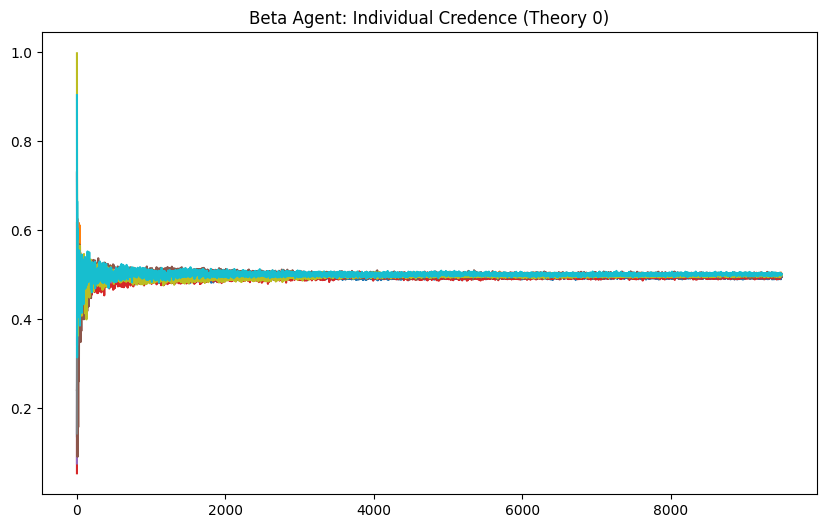

In [9]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()